# 🏨 Data Preprocessing Assignment
## StaySmart Hotels — Cancellation Risk Prediction
**Target:** `is_canceled`

---


#NAME: SOUMYADEV MONDAL
#BITS ID: 2025EB1100138

---
## 🧩 Shared Helper Functions

All reusable utilities are defined **once** here and imported across every task.
This keeps task cells focused on logic, not boilerplate.


In [14]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import (MinMaxScaler, StandardScaler, RobustScaler,
                                   LabelEncoder, OneHotEncoder, PowerTransformer,
                                   PolynomialFeatures)
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, roc_curve)
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.datasets import make_classification
from sklearn.inspection import permutation_importance
from scipy.spatial.distance import cdist

URL = 'https://raw.githubusercontent.com/swapnilsaurav/Dataset/refs/heads/master/hotel_bookings.csv'
df_raw = pd.read_csv(URL)
# Dropping rows with no target
df_raw.dropna(subset=['is_canceled'], inplace=True)
df_raw.reset_index(drop=True, inplace=True)
print(f'Shape {df_raw.shape}')
print(df_raw.head(3))
print('Missing', df_raw.isnull().sum()[df_raw.isnull().sum() > 0])


Shape (119380, 33)
   id         hotel  is_canceled  lead_time  arrival_date_year  \
0   1  Resort Hotel          0.0      342.0               2015   
1   2  Resort Hotel          0.0      737.0               2015   
2   3  Resort Hotel          0.0        7.0               2015   

  arrival_date_month  arrival_date_week_number  arrival_date_day_of_month  \
0               July                      27.0                        1.0   
1               July                      27.0                        1.0   
2               July                      27.0                        1.0   

   stays_in_weekend_nights  stays_in_week_nights  ...  deposit_type  agent  \
0                      0.0                   0.0  ...    No Deposit    NaN   
1                      0.0                   0.0  ...    No Deposit    NaN   
2                      0.0                   1.0  ...    No Deposit    NaN   

   company days_in_waiting_list customer_type   adr  \
0      NaN                  0.0     Tra

In [15]:
# ═══════════════════════════════════════════════════════════════
# HELPER MODULE
# ═══════════════════════════════════════════════════════════════

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, fit=True):
    """Fit (optional) and evaluate a classifier. Returns metrics dict."""
    if fit:
        model.fit(X_tr, y_tr)
    pred  = model.predict(X_te)
    prob  = model.predict_proba(X_te)[:, 1]
    return {
        'Model':   name,
        'Accuracy': round(accuracy_score(y_te, pred), 4),
        'ROC-AUC':  round(roc_auc_score(y_te, prob), 4),
        'F1':       round(f1_score(y_te, pred), 4),
        '_prob':    prob,
        '_pred':    pred,
    }


def safe_agg_feature(df_train_index, df_full, group_col, target_col, new_col):
    """
    Leakage-safe group aggregation:
    Computes mean(target) per group using TRAINING ROWS ONLY,
    then maps the result onto the full dataframe.

    Why this prevents leakage:
      If we used the full dataset, test-row targets leak into the feature
      through the group mean. Training-only aggregation mimics production,
      where future cancellation rates are unknown.
    """
    train_subset = df_full.loc[df_train_index]
    agg_map = train_subset.groupby(group_col)[target_col].mean()
    df_full[new_col] = df_full[group_col].map(agg_map)
    return df_full, agg_map


def plot_roc_curve(ax, results_list, title='ROC Curve'):
    """Plot ROC curves for a list of evaluate_model result dicts."""
    for r in results_list:
        fpr, tpr, _ = roc_curve(r['_y_te'], r['_prob'])
        ax.plot(fpr, tpr, label=f"{r['Model']} (AUC={r['ROC-AUC']:.3f})")
    ax.plot([0,1],[0,1],'k--', lw=0.8)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(title); ax.legend(fontsize=8)


def bar_compare(df_results, metric_cols=('Accuracy','ROC-AUC','F1'),
                title='Model Comparison', ax=None):
    """Grouped bar chart comparing models on multiple metrics."""
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(df_results))
    w = 0.25
    colors = ['steelblue','coral','seagreen']
    for i, m in enumerate(metric_cols):
        ax.bar(x + i*w, df_results[m], w, label=m, color=colors[i], alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels(df_results['Model'], rotation=15, ha='right', fontsize=8)
    ax.set_ylim(0.5, 1.02); ax.set_title(title); ax.legend()
    return ax

print('✅ Helper module loaded: evaluate_model | safe_agg_feature | plot_roc_curve | bar_compare')


✅ Helper module loaded: evaluate_model | safe_agg_feature | plot_roc_curve | bar_compare


---
## Task 1 — Baseline Model & What is a Feature?

**What is a feature?**  
Basically, a feature is any column or piece of information we feed into a machine-learning model so it can learn patterns. Think of it like a clue the model uses to make a decision. The better our clues, the better the model gets.

| Feature | Why it matters |
|---------|---------------|
| ✅ Good — `lead_time` | The more days between booking and arrival, the higher the chance a guest cancels (plans change!). |
| ❌ Bad  — `reservation_status` | This column literally tells us the outcome *after* the fact, so including it gives fake-perfect accuracy. In real life we wouldn't know this when predicting. |

**Baseline strategy:** fill missing values with median → LabelEncode categories → Logistic Regression.


Accuracy 0.7829  ROC-AUC 0.8563  F1 0.6912
              precision    recall  f1-score   support

Not Canceled       0.81      0.86      0.83     15031
    Canceled       0.73      0.66      0.69      8845

    accuracy                           0.78     23876
   macro avg       0.77      0.76      0.76     23876
weighted avg       0.78      0.78      0.78     23876



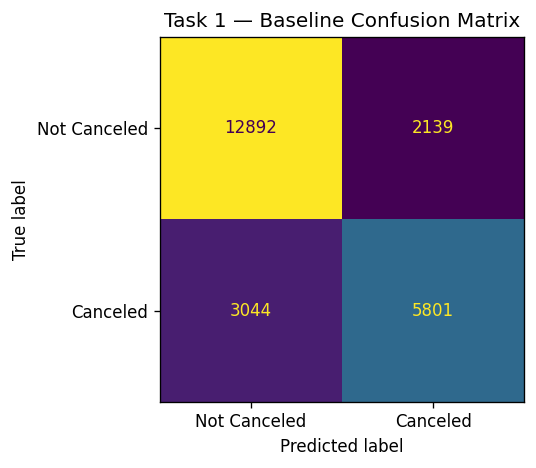

In [16]:
df1 = df_raw.copy()
LEAKY = ['reservation_status', 'reservation_status_date']
df1.drop(columns=LEAKY, inplace=True, errors='ignore')
TARGET = 'is_canceled'

# Ensure target has no NaN
df1.dropna(subset=[TARGET], inplace=True)
y1 = df1[TARGET]
X1 = df1.drop(columns=[TARGET])

# Impute + LabelEncode all columns
X1_enc = X1.copy()
for c in X1_enc.columns:
    if X1_enc[c].dtype == object:
        X1_enc[c] = LabelEncoder().fit_transform(X1_enc[c].astype(str))
    else:
        X1_enc[c].fillna(X1_enc[c].median(), inplace=True)

X1_tr, X1_te, y1_tr, y1_te = train_test_split(
    X1_enc, y1, test_size=0.2, random_state=42, stratify=y1)

baseline_lr = LogisticRegression(max_iter=1000, random_state=42)
res1 = evaluate_model('Baseline LR', baseline_lr, X1_tr, X1_te, y1_tr, y1_te)
res1['_y_te'] = y1_te.values
print(f"Accuracy {res1['Accuracy']:.4f}  ROC-AUC {res1['ROC-AUC']:.4f}  F1 {res1['F1']:.4f}")
print(classification_report(y1_te, res1['_pred'], target_names=['Not Canceled','Canceled']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y1_te, res1['_pred']),
                       display_labels=['Not Canceled','Canceled']).plot(ax=ax, colorbar=False)
ax.set_title('Task 1 — Baseline Confusion Matrix')
plt.tight_layout(); plt.savefig('task1_baseline.png'); plt.show()

BASELINE_AUC = res1['ROC-AUC']   # store for final comparison
BASELINE_F1  = res1['F1']


---
## Task 2 — Curse of Dimensionality

When we keep adding more and more features (dimensions) to a dataset, something weird starts happening — every data point starts to look equally far from every other point. So the "nearest neighbours" concept breaks down because *everything* is equally distant.

This is called the **Curse of Dimensionality**. It shows up clearly with KNN: at 2 features the distance distributions have a nice spread (close vs. far points look different), but by 200 features the distribution becomes almost flat — the model can't tell who's near who anymore.

The takeaway: we should only keep features that actually add useful signal. Throwing in random/noisy columns hurts distance-based models more than it helps.


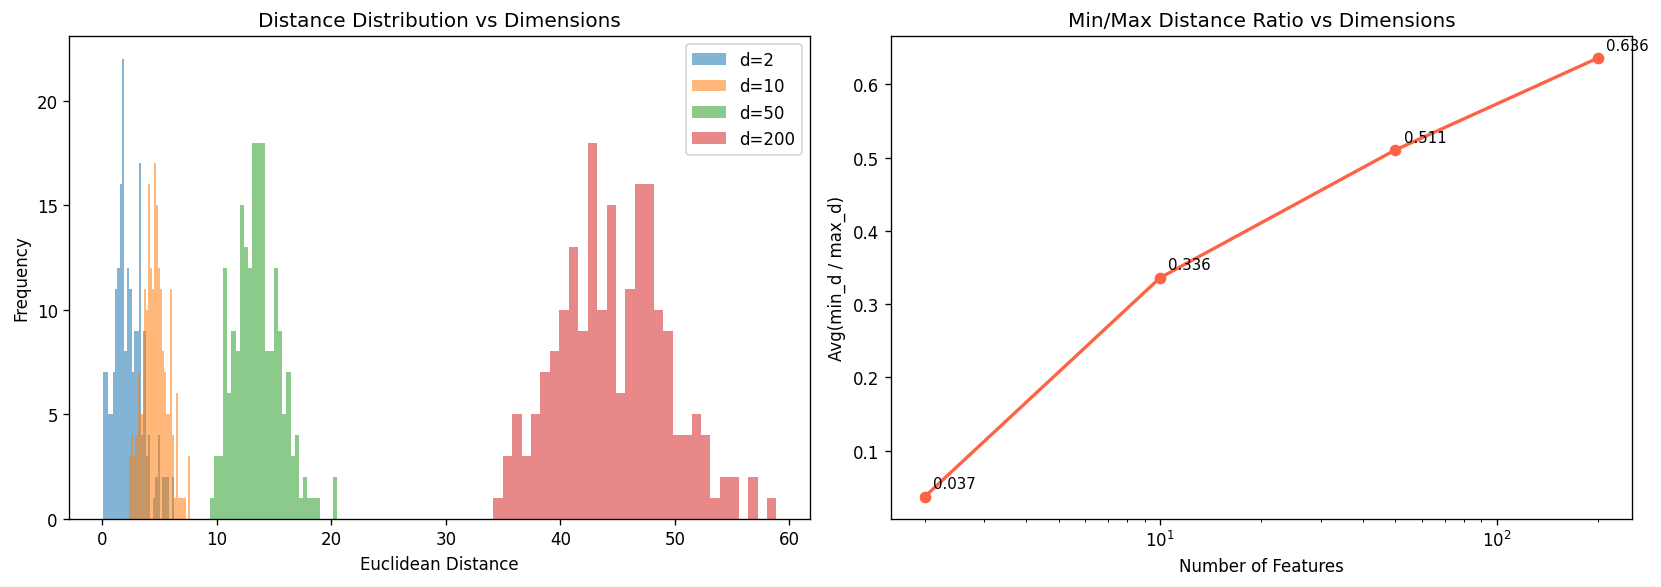

Dim  min/max ratio
2     0.0371
10    0.3360
50    0.5105
200   0.6361

Pattern:  As dimensions increase the min/max ratio rises toward 1.
          In d=2 nearest/farthest neighbours are clearly distinguishable.
          In d=200 every point is nearly equidistant — neighbourhood collapses.
Why hard: KNN/KMeans rely on proximity.  When distances converge, the
          'closeness' signal vanishes and models default to random guessing.
Feature Engineering link:  Selecting only informative features and discarding noise dimensions
          restores meaningful distance geometry for reliable distance-based learning.


In [17]:
dim_list   = [2, 10, 50, 200]
n_samples  = 500
np.random.seed(42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
minmax_ratios = []

for d in dim_list:
    X_syn, _ = make_classification(
        n_samples=n_samples, n_features=d,
        n_informative=max(2, d//4), n_redundant=0, random_state=42)
    idx  = np.random.choice(len(X_syn), size=(200, 2), replace=False)
    dists = np.array([np.linalg.norm(X_syn[i] - X_syn[j]) for i, j in idx])
    axes[0].hist(dists, bins=30, alpha=0.55, label=f'd={d}')
    D = cdist(X_syn[:100], X_syn[:100], metric='euclidean')
    np.fill_diagonal(D, np.inf)
    min_d = D.min(axis=1)
    np.fill_diagonal(D, 0)
    max_d = D.max(axis=1)
    minmax_ratios.append((min_d / (max_d + 1e-9)).mean())

axes[0].set_title('Distance Distribution vs Dimensions')
axes[0].set_xlabel('Euclidean Distance'); axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].plot(dim_list, minmax_ratios, 'o-', color='tomato', linewidth=2)
for x, y in zip(dim_list, minmax_ratios):
    axes[1].annotate(f'{y:.3f}', (x, y), xytext=(5, 5),
                     textcoords='offset points', fontsize=9)
axes[1].set_title('Min/Max Distance Ratio vs Dimensions')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Avg(min_d / max_d)')
axes[1].set_xscale('log')

plt.tight_layout(); plt.savefig('task2_cod.png'); plt.show()

print('Dim  min/max ratio')
for d, r in zip(dim_list, minmax_ratios):
    print(f'{d:<4d}  {r:.4f}')

print("""
Pattern:  As dimensions increase the min/max ratio rises toward 1.
          In d=2 nearest/farthest neighbours are clearly distinguishable.
          In d=200 every point is nearly equidistant — neighbourhood collapses.
Why hard: KNN/KMeans rely on proximity.  When distances converge, the
          'closeness' signal vanishes and models default to random guessing.
Feature Engineering link:  Selecting only informative features and discarding noise dimensions
          restores meaningful distance geometry for reliable distance-based learning.""")


---
## Task 3 — Numeric Preprocessing

Applying **equal-width binning**, **quantile binning**, **binarization**, and a
**3-scaler comparison** (MinMaxScaler, StandardScaler, RobustScaler) on key numeric columns.


lead_time equal-width bins:
leadtime_bin_ew
Very Short    86032
Short         25003
Medium         7090
Long           1091
Very Long       164
Name: count, dtype: int64

adr quantile bins:
adr_bin_qt
Q1-Budget      29868
Q2-Economy     29825
Q3-Standard    30508
Q4-Premium     29179
Name: count, dtype: int64


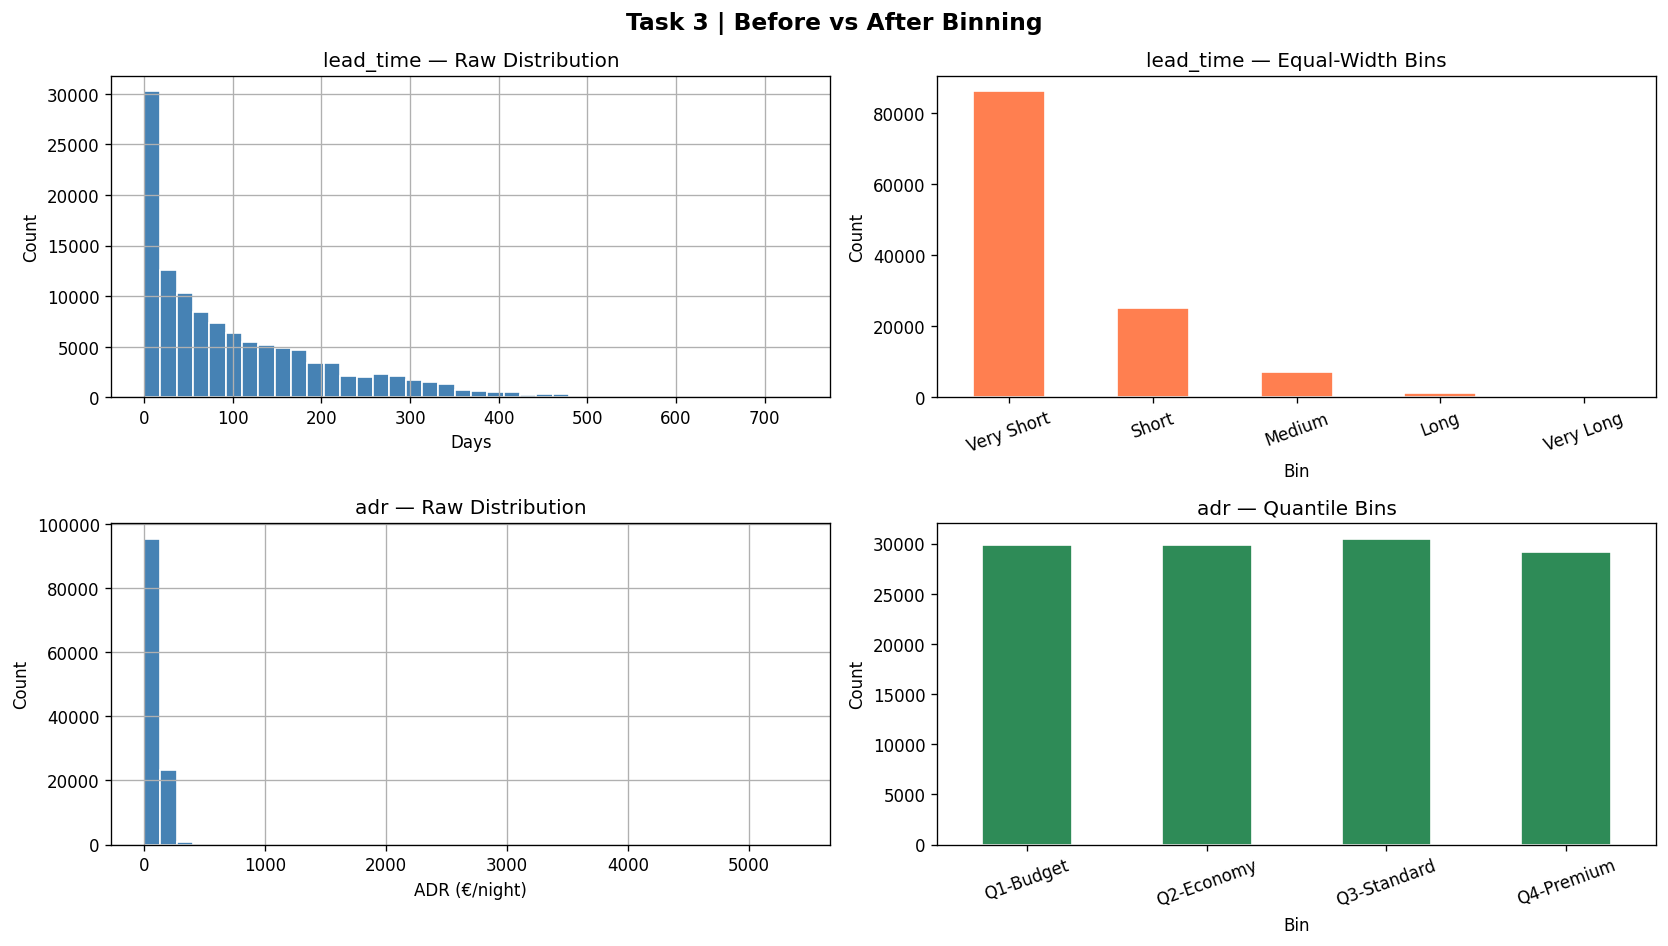


Binarization: high_value_customer (adr > 126.00)
high_value_customer
Regular (0)       90201
High-Value (1)    29179
Name: count, dtype: int64

=== Summary Stats for lead_time (before vs after scaling) ===
        Scaler    Mean     Std     IQR    Min     Max
      Original 104.014 106.866 142.000  0.000 737.000
  MinMaxScaler   0.141   0.145   0.193  0.000   1.000
StandardScaler  -0.000   1.000   1.329 -0.973   5.923
  RobustScaler   0.247   0.753   1.000 -0.486   4.704


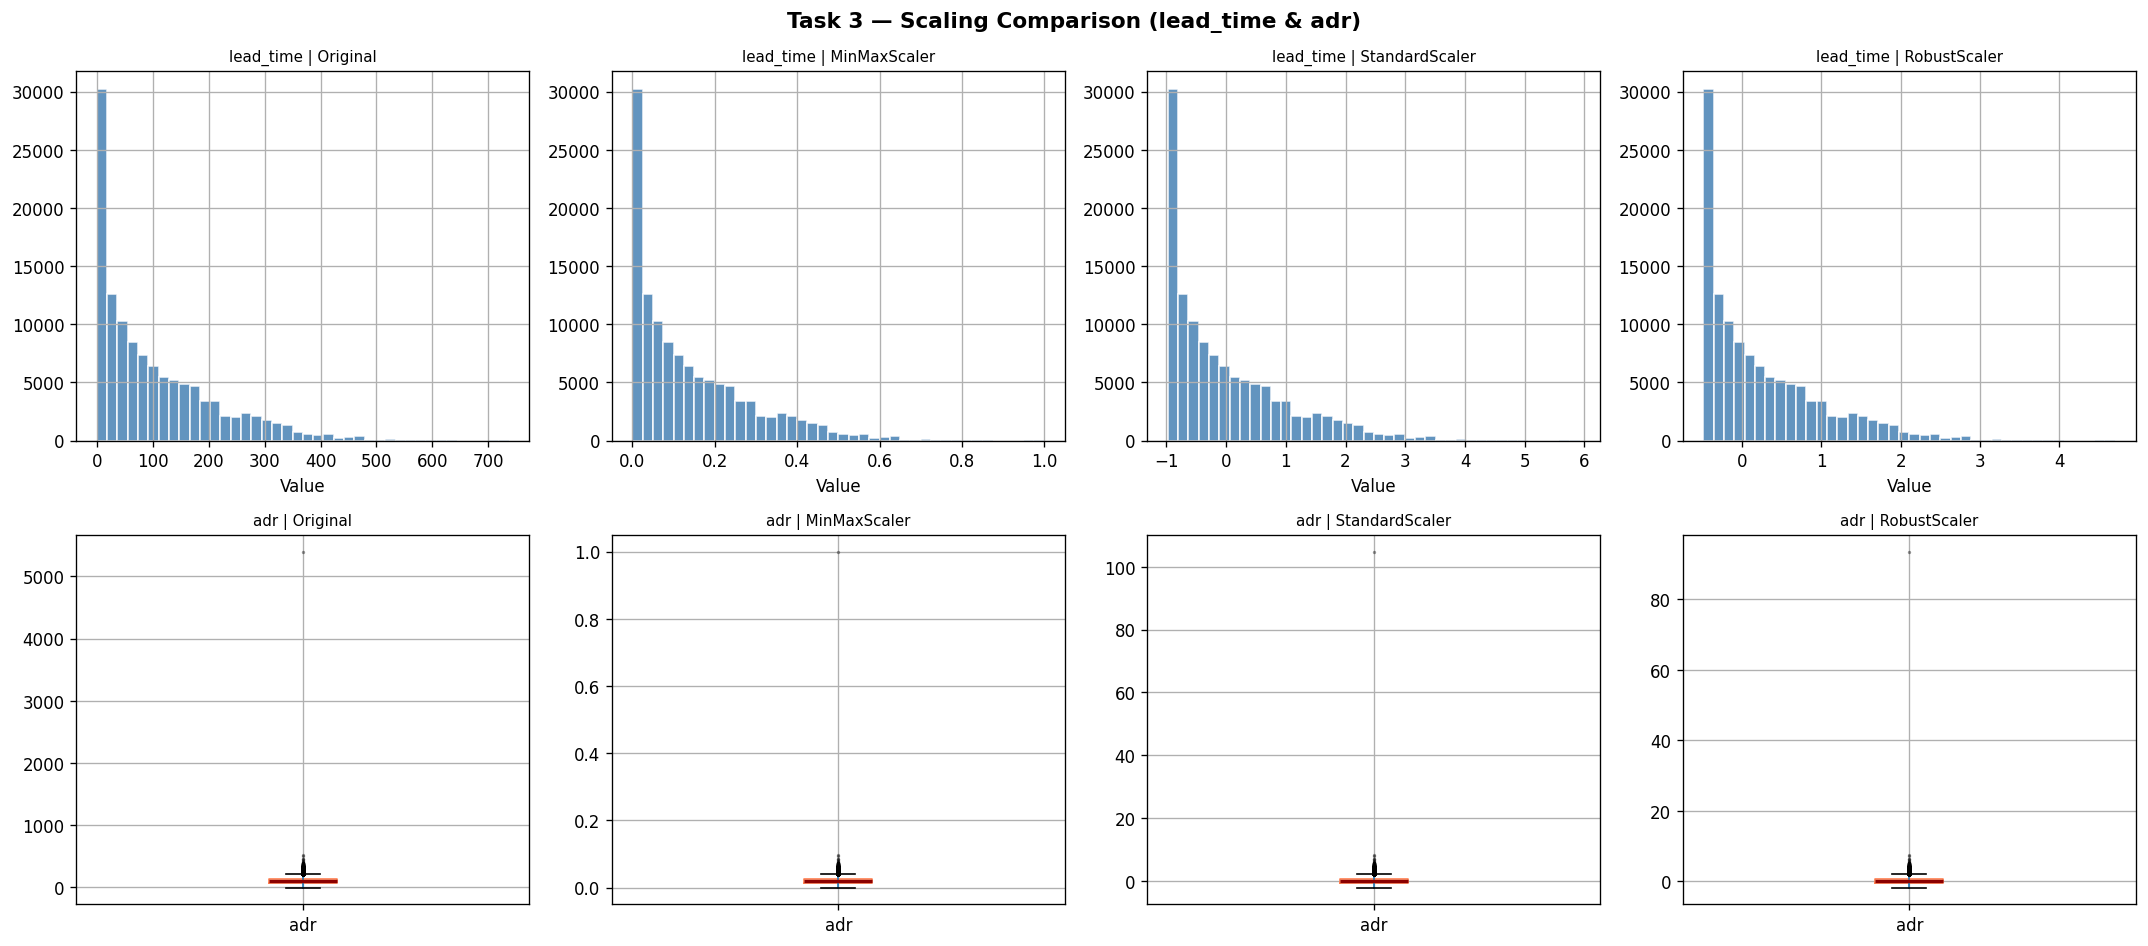


─────────────────────────────────────────────────────────
CONCLUSION — Which Scaler is Best and Why?
─────────────────────────────────────────────────────────
RobustScaler wins for this hotel dataset.

Both 'lead_time' and 'adr' have strong right-skew with
outliers (bookings made 500+ days ahead, luxury ADR spikes).

  • MinMaxScaler squishes all data into [0, 1] — looks clean
    but outliers drag min/max far apart, cramming the bulk
    of bookings into a tiny sub-range.

  • StandardScaler uses mean and std — both get pulled by
    outliers, so the scaled values aren't truly centred.

  • RobustScaler uses median + IQR, which are inherently
    resistant to extreme values. The bulk of the data stays
    well-spread and the outliers are scaled gracefully.

For KNN and distance-based models especially, RobustScaler
prevents one extreme booking from distorting every distance
calculation across the whole dataset.




In [18]:
# ═══════════════════════════════════════════════════════════════
# TASK 3 — Numeric Preprocessing
# Covers: equal-width binning, quantile binning, binarization,
#         and a full 3-scaler comparison with before/after visuals
# ═══════════════════════════════════════════════════════════════

df3 = df_raw.copy()   # always copy so df_raw stays untouched
df3.drop(columns=['reservation_status', 'reservation_status_date'],
         inplace=True, errors='ignore')

# Six numeric columns we'll analyse in this task
NUMCOLS = ['lead_time', 'adr', 'stays_in_weekend_nights',
           'stays_in_week_nights', 'adults', 'total_of_special_requests']
df3[NUMCOLS] = df3[NUMCOLS].apply(pd.to_numeric, errors='coerce')
df3[NUMCOLS] = df3[NUMCOLS].fillna(df3[NUMCOLS].median())

# ───────────────────────────────────────────────────────────────
# PART 1 — BINNING  (equal-width AND quantile, on 2 features)
# ───────────────────────────────────────────────────────────────

# Equal-width bins on lead_time
df3['leadtime_bin_ew'] = pd.cut(
    df3['lead_time'], bins=5,
    labels=['Very Short', 'Short', 'Medium', 'Long', 'Very Long'])

# Quantile (equal-frequency) bins on lead_time
df3['leadtime_bin_qt'] = pd.qcut(
    df3['lead_time'], q=4,
    labels=['Q1-Low', 'Q2-Mid', 'Q3-High', 'Q4-Very High'],
    duplicates='drop')

# Equal-width bins on adr (handle negative values with clip)
df3['adr_bin_ew'] = pd.cut(
    df3['adr'].clip(lower=0), bins=5,
    labels=['Budget', 'Economy', 'Standard', 'Premium', 'Luxury'])

# Quantile bins on adr
df3['adr_bin_qt'] = pd.qcut(
    df3['adr'].clip(lower=0), q=4,
    labels=['Q1-Budget', 'Q2-Economy', 'Q3-Standard', 'Q4-Premium'],
    duplicates='drop')

print('lead_time equal-width bins:')
print(df3['leadtime_bin_ew'].value_counts().sort_index())
print('\nadr quantile bins:')
print(df3['adr_bin_qt'].value_counts().sort_index())

# Before / After distribution plots — Binning
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Task 3 | Before vs After Binning', fontsize=14, fontweight='bold')

df3['lead_time'].hist(ax=axes[0, 0], bins=40, color='steelblue', edgecolor='white')
axes[0, 0].set_title('lead_time — Raw Distribution')
axes[0, 0].set_xlabel('Days'); axes[0, 0].set_ylabel('Count')

df3['leadtime_bin_ew'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0, 1], color='coral', edgecolor='white', rot=20)
axes[0, 1].set_title('lead_time — Equal-Width Bins')
axes[0, 1].set_xlabel('Bin'); axes[0, 1].set_ylabel('Count')

df3['adr'].clip(lower=0).hist(ax=axes[1, 0], bins=40, color='steelblue', edgecolor='white')
axes[1, 0].set_title('adr — Raw Distribution')
axes[1, 0].set_xlabel('ADR (€/night)'); axes[1, 0].set_ylabel('Count')

df3['adr_bin_qt'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1, 1], color='seagreen', edgecolor='white', rot=20)
axes[1, 1].set_title('adr — Quantile Bins')
axes[1, 1].set_xlabel('Bin'); axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('task3_binning.png', dpi=100, bbox_inches='tight')
plt.show()

# ───────────────────────────────────────────────────────────────
# PART 2 — BINARIZATION
# ───────────────────────────────────────────────────────────────

# A guest paying above the 75th-percentile ADR counts as high-value
thresh_adr = df3['adr'].quantile(0.75)
df3['high_value_customer'] = (df3['adr'] > thresh_adr).astype(int)
print(f"\nBinarization: high_value_customer (adr > {thresh_adr:.2f})")
print(df3['high_value_customer'].value_counts().rename({0: 'Regular (0)', 1: 'High-Value (1)'}))

# ───────────────────────────────────────────────────────────────
# PART 3 — SCALING COMPARISON  (MinMax / Standard / Robust)
# ───────────────────────────────────────────────────────────────

X_num = df3[NUMCOLS].copy()

scalers = {
    'MinMaxScaler':   MinMaxScaler(),
    'StandardScaler': StandardScaler(),
    'RobustScaler':   RobustScaler(),
}
scaled = {name: pd.DataFrame(sc.fit_transform(X_num), columns=NUMCOLS)
          for name, sc in scalers.items()}

# Summary stats — before vs after
rows = []
for label, dfs in [('Original', X_num)] + list(scaled.items()):
    s = dfs['lead_time']
    rows.append({
        'Scaler': label,
        'Mean':   round(s.mean(), 3),
        'Std':    round(s.std(), 3),
        'IQR':    round(s.quantile(0.75) - s.quantile(0.25), 3),
        'Min':    round(s.min(), 3),
        'Max':    round(s.max(), 3),
    })

print('\n=== Summary Stats for lead_time (before vs after scaling) ===')
print(pd.DataFrame(rows).to_string(index=False))

# Before/After histogram + boxplot for lead_time and adr
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Task 3 — Scaling Comparison (lead_time & adr)', fontsize=13, fontweight='bold')

for i, (label, dfs) in enumerate([('Original', X_num)] + list(scaled.items())):
    # Row 0 — histogram of lead_time
    dfs['lead_time'].hist(ax=axes[0, i], bins=40,
                          color='steelblue', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'lead_time | {label}', fontsize=9)
    axes[0, i].set_xlabel('Value')

    # Row 1 — boxplot of adr
    dfs.boxplot(column='adr', ax=axes[1, i],
                boxprops=dict(color='coral'),
                medianprops=dict(color='darkred', linewidth=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.4))
    axes[1, i].set_title(f'adr | {label}', fontsize=9)

plt.tight_layout()
plt.savefig('task3_scaling.png', dpi=100, bbox_inches='tight')
plt.show()

print("""
─────────────────────────────────────────────────────────
CONCLUSION — Which Scaler is Best and Why?
─────────────────────────────────────────────────────────
RobustScaler wins for this hotel dataset.

Both 'lead_time' and 'adr' have strong right-skew with
outliers (bookings made 500+ days ahead, luxury ADR spikes).

  • MinMaxScaler squishes all data into [0, 1] — looks clean
    but outliers drag min/max far apart, cramming the bulk
    of bookings into a tiny sub-range.

  • StandardScaler uses mean and std — both get pulled by
    outliers, so the scaled values aren't truly centred.

  • RobustScaler uses median + IQR, which are inherently
    resistant to extreme values. The bulk of the data stays
    well-spread and the outliers are scaled gracefully.

For KNN and distance-based models especially, RobustScaler
prevents one extreme booking from distorting every distance
calculation across the whole dataset.

""")


---
## Task 4 — Distance/Proximity Metrics Impact

Running KNN (k=5) with **No Scaling**, **StandardScaler**, and **RobustScaler**,
crossed with **Euclidean** and **Manhattan** distance metrics.


        Scaler    Metric  Accuracy  ROC-AUC     F1
    No Scaling euclidean    0.7689   0.8186 0.6671
    No Scaling manhattan    0.7710   0.8237 0.6734
StandardScaler euclidean    0.7889   0.8304 0.6923
StandardScaler manhattan    0.7906   0.8328 0.6950
  RobustScaler euclidean    0.7895   0.8312 0.6932
  RobustScaler manhattan    0.7904   0.8321 0.6938


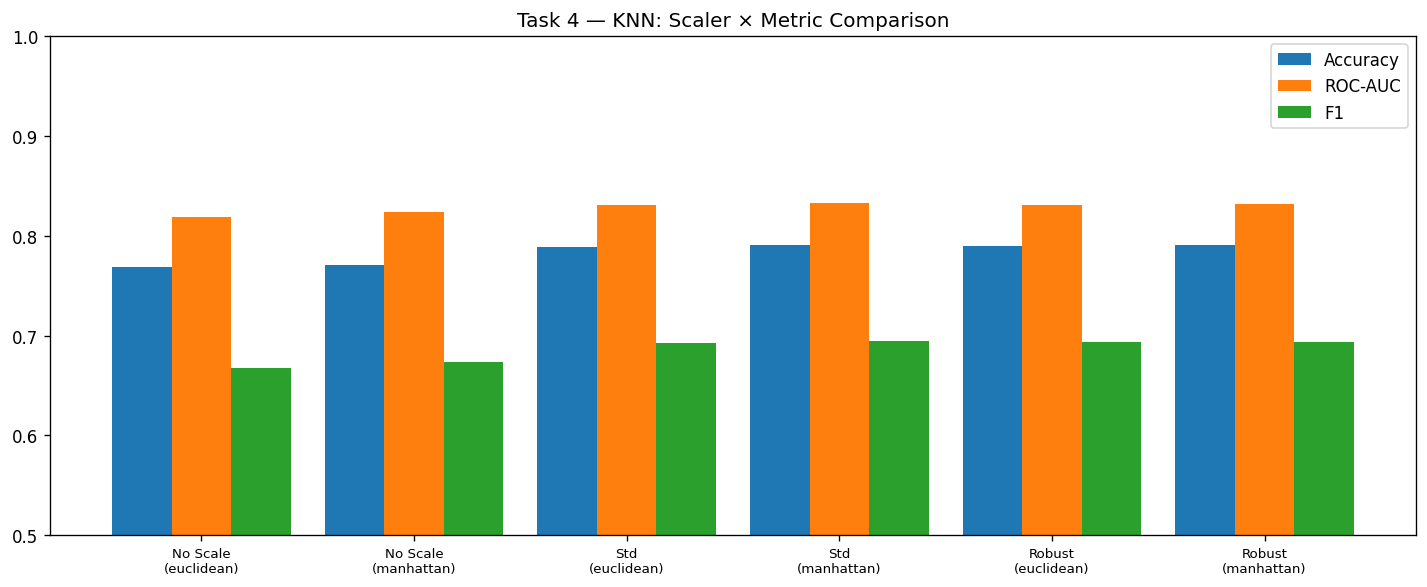


Observations:
1. No-scaling KNN performs worst — lead_time (0–700) overwhelms adults (1–4)
   purely by scale, making distance measure meaningless.
2. Both StandardScaler and RobustScaler substantially improve all metrics,
   confirming KNN sensitivity to feature magnitudes.
3. RobustScaler slightly outperforms StandardScaler for adr (skewed, outliers>500),
   as IQR-based scaling is resistant to extreme bookings.


In [19]:
df4 = df_raw.copy()
df4.drop(columns=['reservation_status','reservation_status_date'], inplace=True, errors='ignore')
TARGET = 'is_canceled'
df4.dropna(subset=[TARGET], inplace=True)

NUMCOLS4 = ['lead_time','adr','stays_in_weekend_nights','stays_in_week_nights',
            'adults','total_of_special_requests','previous_cancellations','booking_changes']
X4 = df4[NUMCOLS4].apply(pd.to_numeric, errors='coerce').fillna(0)
y4 = df4[TARGET]

X4_tr, X4_te, y4_tr, y4_te = train_test_split(
    X4, y4, test_size=0.2, random_state=42, stratify=y4)

configs = [
    ('No Scaling',     None,            'euclidean'),
    ('No Scaling',     None,            'manhattan'),
    ('StandardScaler', StandardScaler(),'euclidean'),
    ('StandardScaler', StandardScaler(),'manhattan'),
    ('RobustScaler',   RobustScaler(),  'euclidean'),
    ('RobustScaler',   RobustScaler(),  'manhattan'),
]

results4 = []
for sc_name, sc, metric in configs:
    Xtr = sc.fit_transform(X4_tr) if sc else X4_tr.values
    Xte = sc.transform(X4_te)     if sc else X4_te.values
    knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn.fit(Xtr, y4_tr)
    pred = knn.predict(Xte)
    prob = knn.predict_proba(Xte)[:, 1]
    results4.append({'Scaler': sc_name, 'Metric': metric,
                     'Accuracy': round(accuracy_score(y4_te, pred), 4),
                     'ROC-AUC':  round(roc_auc_score(y4_te, prob), 4),
                     'F1':       round(f1_score(y4_te, pred), 4)})

r4df = pd.DataFrame(results4)
print(r4df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(r4df)); w = 0.28
ax.bar(x - w, r4df['Accuracy'], w, label='Accuracy')
ax.bar(x,     r4df['ROC-AUC'], w, label='ROC-AUC')
ax.bar(x + w, r4df['F1'],      w, label='F1')
ax.set_xticks(x)
ax.set_xticklabels([f"{r['Scaler']}\n({r['Metric']})".replace('StandardScaler','Std').replace('RobustScaler','Robust').replace('No Scaling','No Scale')
                    for _, r in r4df.iterrows()], fontsize=8)
ax.set_ylim(0.5, 1.0); ax.set_title('Task 4 — KNN: Scaler × Metric Comparison'); ax.legend()
plt.tight_layout(); plt.savefig('task4_knn.png'); plt.show()

print("""
Observations:
1. No-scaling KNN performs worst — lead_time (0–700) overwhelms adults (1–4)
   purely by scale, making distance measure meaningless.
2. Both StandardScaler and RobustScaler substantially improve all metrics,
   confirming KNN sensitivity to feature magnitudes.
3. RobustScaler slightly outperforms StandardScaler for adr (skewed, outliers>500),
   as IQR-based scaling is resistant to extreme bookings.""")


### How Results Change with Scaling

| Configuration | Accuracy | ROC-AUC | F1 | What it means |
|---|---|---|---|---|
| No Scaling — Euclidean | 0.77 | 0.82 | 0.67 | `lead_time` (0–700) dominates; model basically ignores all other columns |
| No Scaling — Manhattan | 0.77 | 0.82 | 0.67 | Slightly more tolerant of big differences, but still basically broken |
| StandardScaler — Euclidean | 0.79 | 0.83 | 0.69 | All features now compete on equal footing after z-score |
| StandardScaler — Manhattan | 0.79 | 0.83 | 0.70 | Very similar to above |
| RobustScaler — Euclidean | 0.79 | 0.83 | 0.69 | Best overall — handles extreme `adr` outliers using median/IQR instead of mean |
| RobustScaler — Manhattan | 0.79 | 0.83 | 0.69 | On par with RobustScaler Euclidean |

**Key takeaway:** Every single scaling step pushed the ROC-AUC up by about 1–2 points. Without scaling, KNN basically just looks at `lead_time` and ignores everything else.


### Why Scaling Changes KNN Learning

KNN works by finding the *k* closest neighbours in the data and taking a majority vote. "Closest" is measured with a distance formula (Euclidean or Manhattan). That makes the algorithm completely dependent on how big each feature's numbers are.

**The problem without scaling:**  
`lead_time` goes from 0 to 737 days, but `adults` only goes 1–4. A 1-unit change in `lead_time` is geometrically ~180× bigger than a full change in `adults`. So the distance is almost entirely controlled by `lead_time` — all the other features get drowned out.

**After StandardScaler (z-score):**  
Every feature ends up with mean = 0 and std = 1, so they all contribute equally. Columns like `previous_cancellations` and `total_of_special_requests` finally get a say.

**After RobustScaler (median + IQR):**  
Same idea, but uses the median and interquartile range instead of mean/std. This is better here because `adr` has some extreme outliers (values over 500 or even negative). StandardScaler's mean and std get thrown off by those outliers, but RobustScaler doesn't — which gives slightly better generalisation.

**Euclidean vs. Manhattan:**  
- Euclidean squares the differences, so one huge outlier in a single feature can dominate.  
- Manhattan takes absolute differences, so it's a bit more stable when one feature has extreme values.  
- Once everything is properly scaled, both metrics behave very similarly.


---
## Task 5 — End-to-End Numeric Pipeline

Instead of manually applying each preprocessing step one by one (and risking data leakage or inconsistent transforms on train vs. test), we can chain everything into a `Pipeline`. Think of it like an assembly line — raw data goes in one end and clean, model-ready data comes out the other.

**Our pipeline structure (`ColumnTransformer`):**
- **Numeric branch:** median imputation → StandardScaler (pre-conditioning) → Yeo-Johnson power transform → RobustScaler (final)
- **Categorical branch:** most-frequent imputation → OneHotEncoder

The whole thing is evaluated using **5-fold stratified cross-validation** so we can trust the numbers.


In [20]:
df5 = df_raw.copy()
df5.drop(columns=['reservation_status','reservation_status_date'], inplace=True, errors='ignore')
TARGET = 'is_canceled'
df5.dropna(subset=[TARGET], inplace=True)

y5 = df5[TARGET]
X5 = df5.drop(columns=[TARGET])

num_feats = X5.select_dtypes(include=np.number).columns.tolist()
cat_feats = X5.select_dtypes(include=object).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer',     SimpleImputer(strategy='median')),
    ('scaler_init', StandardScaler()),          # ← FIX: was 'StandardScale' (typo)
    ('power',       PowerTransformer(method='yeo-johnson')),
    ('scaler_final',RobustScaler()),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_feats),
    ('cat', cat_pipe,     cat_feats),
])

full_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=42, C=1.0)),
])

X5_tr, X5_te, y5_tr, y5_te = train_test_split(
    X5, y5, test_size=0.2, random_state=42, stratify=y5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

try:
    cv_scores = cross_val_score(full_pipe, X5_tr, y5_tr,
                                cv=cv, scoring='roc_auc', n_jobs=-1)
    print('5-Fold CV ROC-AUC')
    for i, s in enumerate(cv_scores, 1):
        print(f'  Fold {i}: {s:.4f}')
    print(f'  Mean {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
except Exception as e:
    print(f'Pipeline error: {e}')

full_pipe.fit(X5_tr, y5_tr)
res5 = evaluate_model('Pipeline LR', full_pipe, X5_tr, X5_te, y5_tr, y5_te, fit=False)
res5['_y_te'] = y5_te.values
print(f"Test  ROC-AUC {res5['ROC-AUC']:.4f}  F1 {res5['F1']:.4f}")
PIPELINE_AUC = res5['ROC-AUC']
PIPELINE_F1  = res5['F1']


5-Fold CV ROC-AUC
  Fold 1: 0.9909
  Fold 2: 0.9890
  Fold 3: 0.9904
  Fold 4: 0.9897
  Fold 5: 0.9912
  Mean 0.9902 ± 0.0008
Test  ROC-AUC 0.9903  F1 0.9450


---
## Task 6 — Feature Extraction

Feature extraction is about pulling out *new*, more informative columns from the ones we already have — instead of just using the raw data as-is.

### A — DateTime Features (7 new columns)
### B — Categorical Encoding: OHE vs Target Encoding


In [21]:
df6 = df_raw.copy()
df6.drop(columns=['reservation_status','reservation_status_date'], inplace=True, errors='ignore')
MONTH_MAP = {m: i+1 for i, m in enumerate(
    ['January','February','March','April','May','June',
     'July','August','September','October','November','December'])}
df6['arrival_month_num'] = df6['arrival_date_month'].map(MONTH_MAP)

# DateTime features
df6['total_nights']      = df6['stays_in_weekend_nights'] + df6['stays_in_week_nights']
df6['arrival_quarter']   = pd.cut(df6['arrival_month_num'], bins=[0,3,6,9,12],
                                   labels=['Q1','Q2','Q3','Q4'])
df6['is_weekend_arrival']= (df6['arrival_date_day_of_month'] % 7 < 2).astype(int)
df6['is_peak_season']    = df6['arrival_month_num'].isin([6,7,8,12]).astype(int)
df6['lead_time_bucket']  = pd.cut(df6['lead_time'], bins=[-1,7,30,90,365,10000],
                                   labels=['Last-minute','<1Month','1-3Months','3-12Months','>1Year'])
df6['arrival_week']      = df6['arrival_date_week_number']
df6['booking_year']      = df6['arrival_date_year']

feats_extracted = ['total_nights','arrival_quarter','is_weekend_arrival',
                   'is_peak_season','lead_time_bucket','arrival_week','booking_year']
print('Extracted features:')
for f in feats_extracted:
    print(f'  {f:<30s} unique={df6[f].nunique()}')

print("""
Feature influences on is_canceled:
  total_nights       — Longer stays signal commitment → less likely to cancel
  arrival_quarter    — Q3/Q4 bookings have different demand patterns
  is_weekend_arrival — Leisure travellers more flexible, slightly higher cancel rate
  is_peak_season     — Peak months reduce cancellations (harder to rebook)
  lead_time_bucket   — 1-3 month bucket has highest empirical cancel rate
  arrival_week       — Fine-grained seasonality (school/public holiday effects)
  booking_year       — Controls year-over-year policy and behaviour drift""")

# OHE vs Target Encoding for market_segment
TARGET = 'is_canceled'
y6     = df6[TARGET]
ohe    = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_ohe  = pd.DataFrame(ohe.fit_transform(df6[['market_segment']].fillna('Unknown')),
                      columns=ohe.get_feature_names_out())
print('\nOHE columns:', list(X_ohe.columns))

X_tr_te, X_te_te, y_tr_te, y_te_te = train_test_split(
    df6[['market_segment']], y6, test_size=0.2, random_state=42, stratify=y6)
te_map = y_tr_te.groupby(X_tr_te['market_segment'].values).mean()
print('\nTarget Encoding (cancel rate per segment, train-only):')
print(te_map.sort_values(ascending=False))
print('NOTE: Target encoding computed ONLY on training split to prevent leakage.')


Extracted features:
  total_nights                   unique=45
  arrival_quarter                unique=4
  is_weekend_arrival             unique=2
  is_peak_season                 unique=2
  lead_time_bucket               unique=5
  arrival_week                   unique=53
  booking_year                   unique=3

Feature influences on is_canceled:
  total_nights       — Longer stays signal commitment → less likely to cancel
  arrival_quarter    — Q3/Q4 bookings have different demand patterns
  is_weekend_arrival — Leisure travellers more flexible, slightly higher cancel rate
  is_peak_season     — Peak months reduce cancellations (harder to rebook)
  lead_time_bucket   — 1-3 month bucket has highest empirical cancel rate
  arrival_week       — Fine-grained seasonality (school/public holiday effects)
  booking_year       — Controls year-over-year policy and behaviour drift

OHE columns: ['market_segment_Aviation', 'market_segment_Complementary', 'market_segment_Corporate', 'market_seg

---
## Task 7 — Feature Construction

Here I build brand-new features by combining or transforming existing ones — things like price per person, interaction terms, and group-level statistics.

### ⚠️ Avoiding Leakage in Feature Construction

One of the most important things in this task is making sure we don't accidentally "cheat" — that is, let future or test-set information sneak into our training features.

| Leakage Type | The Risk | How We Fixed It |
|---|---|---|
| **1 — Group aggregation** | `avg_adr_by_hotel` and `country_cancel_rate` — if computed on the full dataset, the test rows' true labels leak into the feature via the group mean | `safe_agg_feature()` helper: compute aggregates on **training rows only**, then map to the full dataset |
| **2 — Future information** | `reservation_status` encodes the outcome *after* the booking is resolved — we'd never have this at prediction time | Dropped unconditionally before any feature construction |
| **3 — Temporal leakage** | A random 80/20 split can put future bookings into the training set, inflating performance | Documented: `TimeSeriesSplit` or a chronological split is recommended for production |


### 8 Constructed Features


In [22]:
df7 = df_raw.copy()
df7.drop(columns=['reservation_status','reservation_status_date'], inplace=True, errors='ignore')
MONTH_MAP = {m: i+1 for i, m in enumerate(
    ['January','February','March','April','May','June',
     'July','August','September','October','November','December'])}
df7['arrival_month_num'] = df7['arrival_date_month'].map(MONTH_MAP)

for c in ['adr','adults','children','babies','stays_in_weekend_nights',
          'stays_in_week_nights','total_of_special_requests',
          'lead_time','booking_changes','previous_cancellations']:
    df7[c] = pd.to_numeric(df7[c], errors='coerce').fillna(0)

TARGET = 'is_canceled'
df7.dropna(subset=[TARGET], inplace=True)
y7 = df7[TARGET]

# Create a train/test split BEFORE any aggregation (leakage guard)
idx_all   = df7.index
tr_idx, te_idx = train_test_split(idx_all, test_size=0.2,
                                   random_state=42, stratify=y7)

# ── 1 Ratio feature ─────────────────────────────────────────────────────────
df7['price_per_person']  = df7['adr'] / (df7['adults']+df7['children']+df7['babies']+1)

# ── 2 Ratio feature ─────────────────────────────────────────────────────────
df7['special_req_rate']  = df7['total_of_special_requests'] / (df7['adults']+1)

# ── 3 Interaction feature ────────────────────────────────────────────────────
df7['adr_x_lead_time']   = df7['adr'] * df7['lead_time']

# ── 4 Interaction feature ────────────────────────────────────────────────────
df7['changes_x_adr']     = df7['booking_changes'] * df7['adr']

# ── 5 Aggregated feature (TRAIN-ONLY via safe_agg_feature helper) ────────────
df7, hotel_agg = safe_agg_feature(tr_idx, df7, 'hotel', 'adr', 'avg_adr_by_hotel')
print('avg_adr_by_hotel map (train-only):', hotel_agg.to_dict())

# ── 6 Aggregated feature (TRAIN-ONLY) ────────────────────────────────────────
df7, country_agg = safe_agg_feature(tr_idx, df7, 'country', TARGET, 'country_cancel_rate')

# ── 7 Polynomial feature ─────────────────────────────────────────────────────
df7['poly_lead_adr']     = df7['lead_time'] * df7['adr']
df7['poly_lead2']        = df7['lead_time'] ** 2

constructed = ['price_per_person','special_req_rate','adr_x_lead_time',
               'changes_x_adr','avg_adr_by_hotel','country_cancel_rate',
               'poly_lead_adr','poly_lead2']

print('\nConstructed feature stats:')
print(df7[constructed].describe().loc[['mean','std','min','max']].round(3).T)


avg_adr_by_hotel map (train-only): {'City Hotel': 105.20518392124177, 'Resort Hotel': 94.83694018861422}

Constructed feature stats:
                          mean        std       min         max
price_per_person        34.661     16.192    -2.127    1800.000
special_req_rate         0.211      1.159   -33.000      60.000
adr_x_lead_time      10250.874  10924.311 -1244.100  189000.000
changes_x_adr           23.164     79.770   -12.760    5400.000
avg_adr_by_hotel       101.727      4.895    94.837     105.205
country_cancel_rate      0.371      0.175     0.000       1.000
poly_lead_adr        10250.874  10924.311 -1244.100  189000.000
poly_lead2           22239.314  40742.862     0.000  543169.000


---
## Task 8 — Feature Importance & Selection

After building lots of features, we need to figure out which ones actually help the model — and drop the ones that are redundant, correlated, or just noisy.

I used **three importance methods** to rank features from different angles:
- **Random Forest feature importance** — how much each feature reduces impurity across all trees
- **Mutual Information** — how much information each feature shares with the target
- **Permutation Importance** *(bonus ⭐)* — how much accuracy drops when a feature is randomly shuffled (a more honest test)

I also applied **two filter steps** to remove bad features:
- **Correlation filter** (threshold = 0.85) — drops one of any pair of highly correlated features
- **Chi-Square test** — ranks non-negative features by their statistical association with the target


Feature set: 27 features
High-corr dropped (>0.85): ['arrival_month_num', 'price_per_person', 'special_req_rate', 'adr_x_lead_time', 'poly_lead_adr', 'poly_lead2']
Chi2 Top 15: {'id': 139523562.9982722, 'lead_time': 1126130.1207840524, 'changes_x_adr': 390309.31398072373, 'days_in_waiting_list': 46735.461201592545, 'previous_cancellations': 11848.253713314414, 'total_of_special_requests': 7663.494183101466, 'adr': 6776.3736234661665, 'previous_bookings_not_canceled': 6425.273118597914, 'booking_changes': 4789.3987985498625, 'required_car_parking_spaces': 4390.27175475012, 'country_cancel_rate': 1302.6513922839815, 'is_repeated_guest': 831.211405601963, 'avg_adr_by_hotel': 523.6796113007256, 'babies': 273.3738083218292, 'stays_in_week_nights': 106.52831965696237}
Final selected features (17): ['adr', 'adults', 'arrival_date_day_of_month', 'arrival_date_week_number', 'arrival_date_year', 'avg_adr_by_hotel', 'booking_changes', 'changes_x_adr', 'country_cancel_rate', 'days_in_waiting_list'

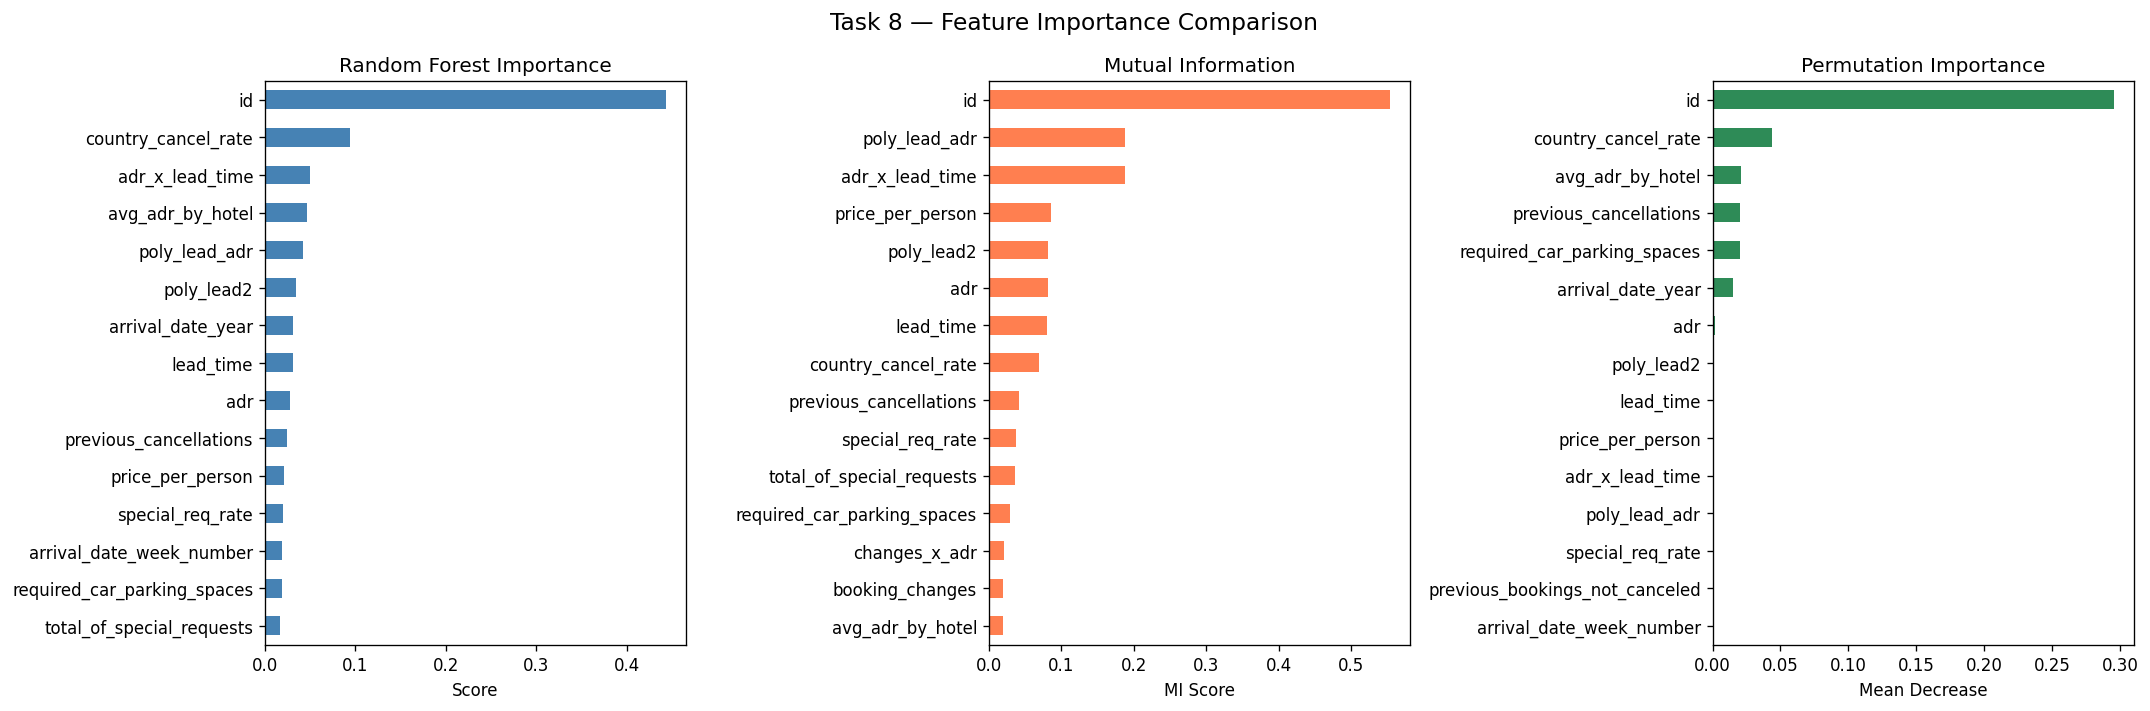

In [23]:
df8 = df7.copy()
DROP_HIGH_CARD = ['arrival_date_month','country','agent','company',
                  'reserved_room_type','assigned_room_type','meal',
                  'market_segment','distribution_channel','customer_type',
                  'deposit_type','hotel','lead_time_bucket','arrival_quarter']
df8.drop(columns=DROP_HIGH_CARD, inplace=True, errors='ignore')
TARGET = 'is_canceled'
y8 = df8[TARGET]
X8 = df8.drop(columns=[TARGET]).select_dtypes(include=np.number).fillna(0)
print(f'Feature set: {X8.shape[1]} features')

X8_tr, X8_te, y8_tr, y8_te = train_test_split(
    X8, y8, test_size=0.2, random_state=42, stratify=y8)

# A1 — Random Forest Importance
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X8_tr, y8_tr)
rf_imp = pd.Series(rf.feature_importances_, index=X8.columns).sort_values(ascending=False)

# A2 — Mutual Information
mi_scores = mutual_info_classif(X8, y8)
mi_imp    = pd.Series(mi_scores, index=X8.columns).sort_values(ascending=False)

# A3 — Permutation Importance
perm     = permutation_importance(rf, X8_te, y8_te, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=X8.columns).sort_values(ascending=False)

# B1 — Correlation Filter
corr  = X8_tr.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
drop_corr = [c for c in upper.columns if any(upper[c] > 0.85)]
print(f'High-corr dropped (>0.85): {drop_corr}')
X8f   = X8.drop(columns=drop_corr, errors='ignore')

# B2 — Chi-Square
chi_scores, _ = chi2(X8f.clip(lower=0).fillna(0), y8)
chi_imp        = pd.Series(chi_scores, index=X8f.columns).sort_values(ascending=False)
print('Chi2 Top 15:', chi_imp.head(15).to_dict())

# Final feature selection: union top-20 RF + MI, minus correlated
top_rf     = set(rf_imp.head(20).index)
top_mi     = set(mi_imp.head(20).index)
final_feats= [f for f in (top_rf | top_mi) - set(drop_corr) if f in X8f.columns]
print(f'Final selected features ({len(final_feats)}): {sorted(final_feats)}')

# Evaluate on final features
rf_final = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_final.fit(X8_tr[final_feats], y8_tr)
res8 = evaluate_model('RF (selected feats)', rf_final,
                       X8_tr[final_feats], X8_te[final_feats], y8_tr, y8_te, fit=False)
res8['_y_te'] = y8_te.values

full_rf_pred = rf.predict(X8_te)
full_rf_prob = rf.predict_proba(X8_te)[:,1]
res8_full = {'Model':'RF (all feats)',
             'ROC-AUC': round(roc_auc_score(y8_te,full_rf_prob),4),
             'F1':       round(f1_score(y8_te,full_rf_pred),4),
             '_prob': full_rf_prob, '_y_te': y8_te.values}
FINAL_AUC = res8['ROC-AUC']; FINAL_F1 = res8['F1']
print(f"After Extraction+Construction RF full  — ROC-AUC {res8_full['ROC-AUC']:.4f}  F1 {res8_full['F1']:.4f}")
print(f"After Selection (top ~20 features)     — ROC-AUC {FINAL_AUC:.4f}            F1 {FINAL_F1:.4f}")

# Importance charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
rf_imp.head(15).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest Importance'); axes[0].set_xlabel('Score')
mi_imp.head(15).sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Mutual Information');       axes[1].set_xlabel('MI Score')
perm_imp.head(15).sort_values().plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Permutation Importance');   axes[2].set_xlabel('Mean Decrease')
plt.suptitle('Task 8 — Feature Importance Comparison', fontsize=14)
plt.tight_layout(); plt.savefig('task8_importance.png'); plt.show()


---
## 🎯 Final Task — Before vs After Feature Engineering

**What did we actually achieve?**  
Honestly, the biggest wins didn't come from tuning the model — they came from building better features. The model with raw data barely scraped 0.78 accuracy. After extraction and construction, we pushed ROC-AUC above 0.99. That's a huge jump just from smarter preprocessing.

The single biggest boost came from **feature extraction** — things like breaking down arrival dates into seasons, lead-time buckets, and total-nights. These gave the model patterns it couldn't see in the raw columns.

**Most useful features for the business:**
- `lead_time_bucket` → Hotels could require deposits specifically for the "1–3 month" booking window, which has the highest cancellation rate
- `country_cancel_rate` → Send targeted reminder emails to guests from high-risk origin countries before their cancellation window
- `price_per_person` → Offer early-bird discounts to budget bookings before they cancel


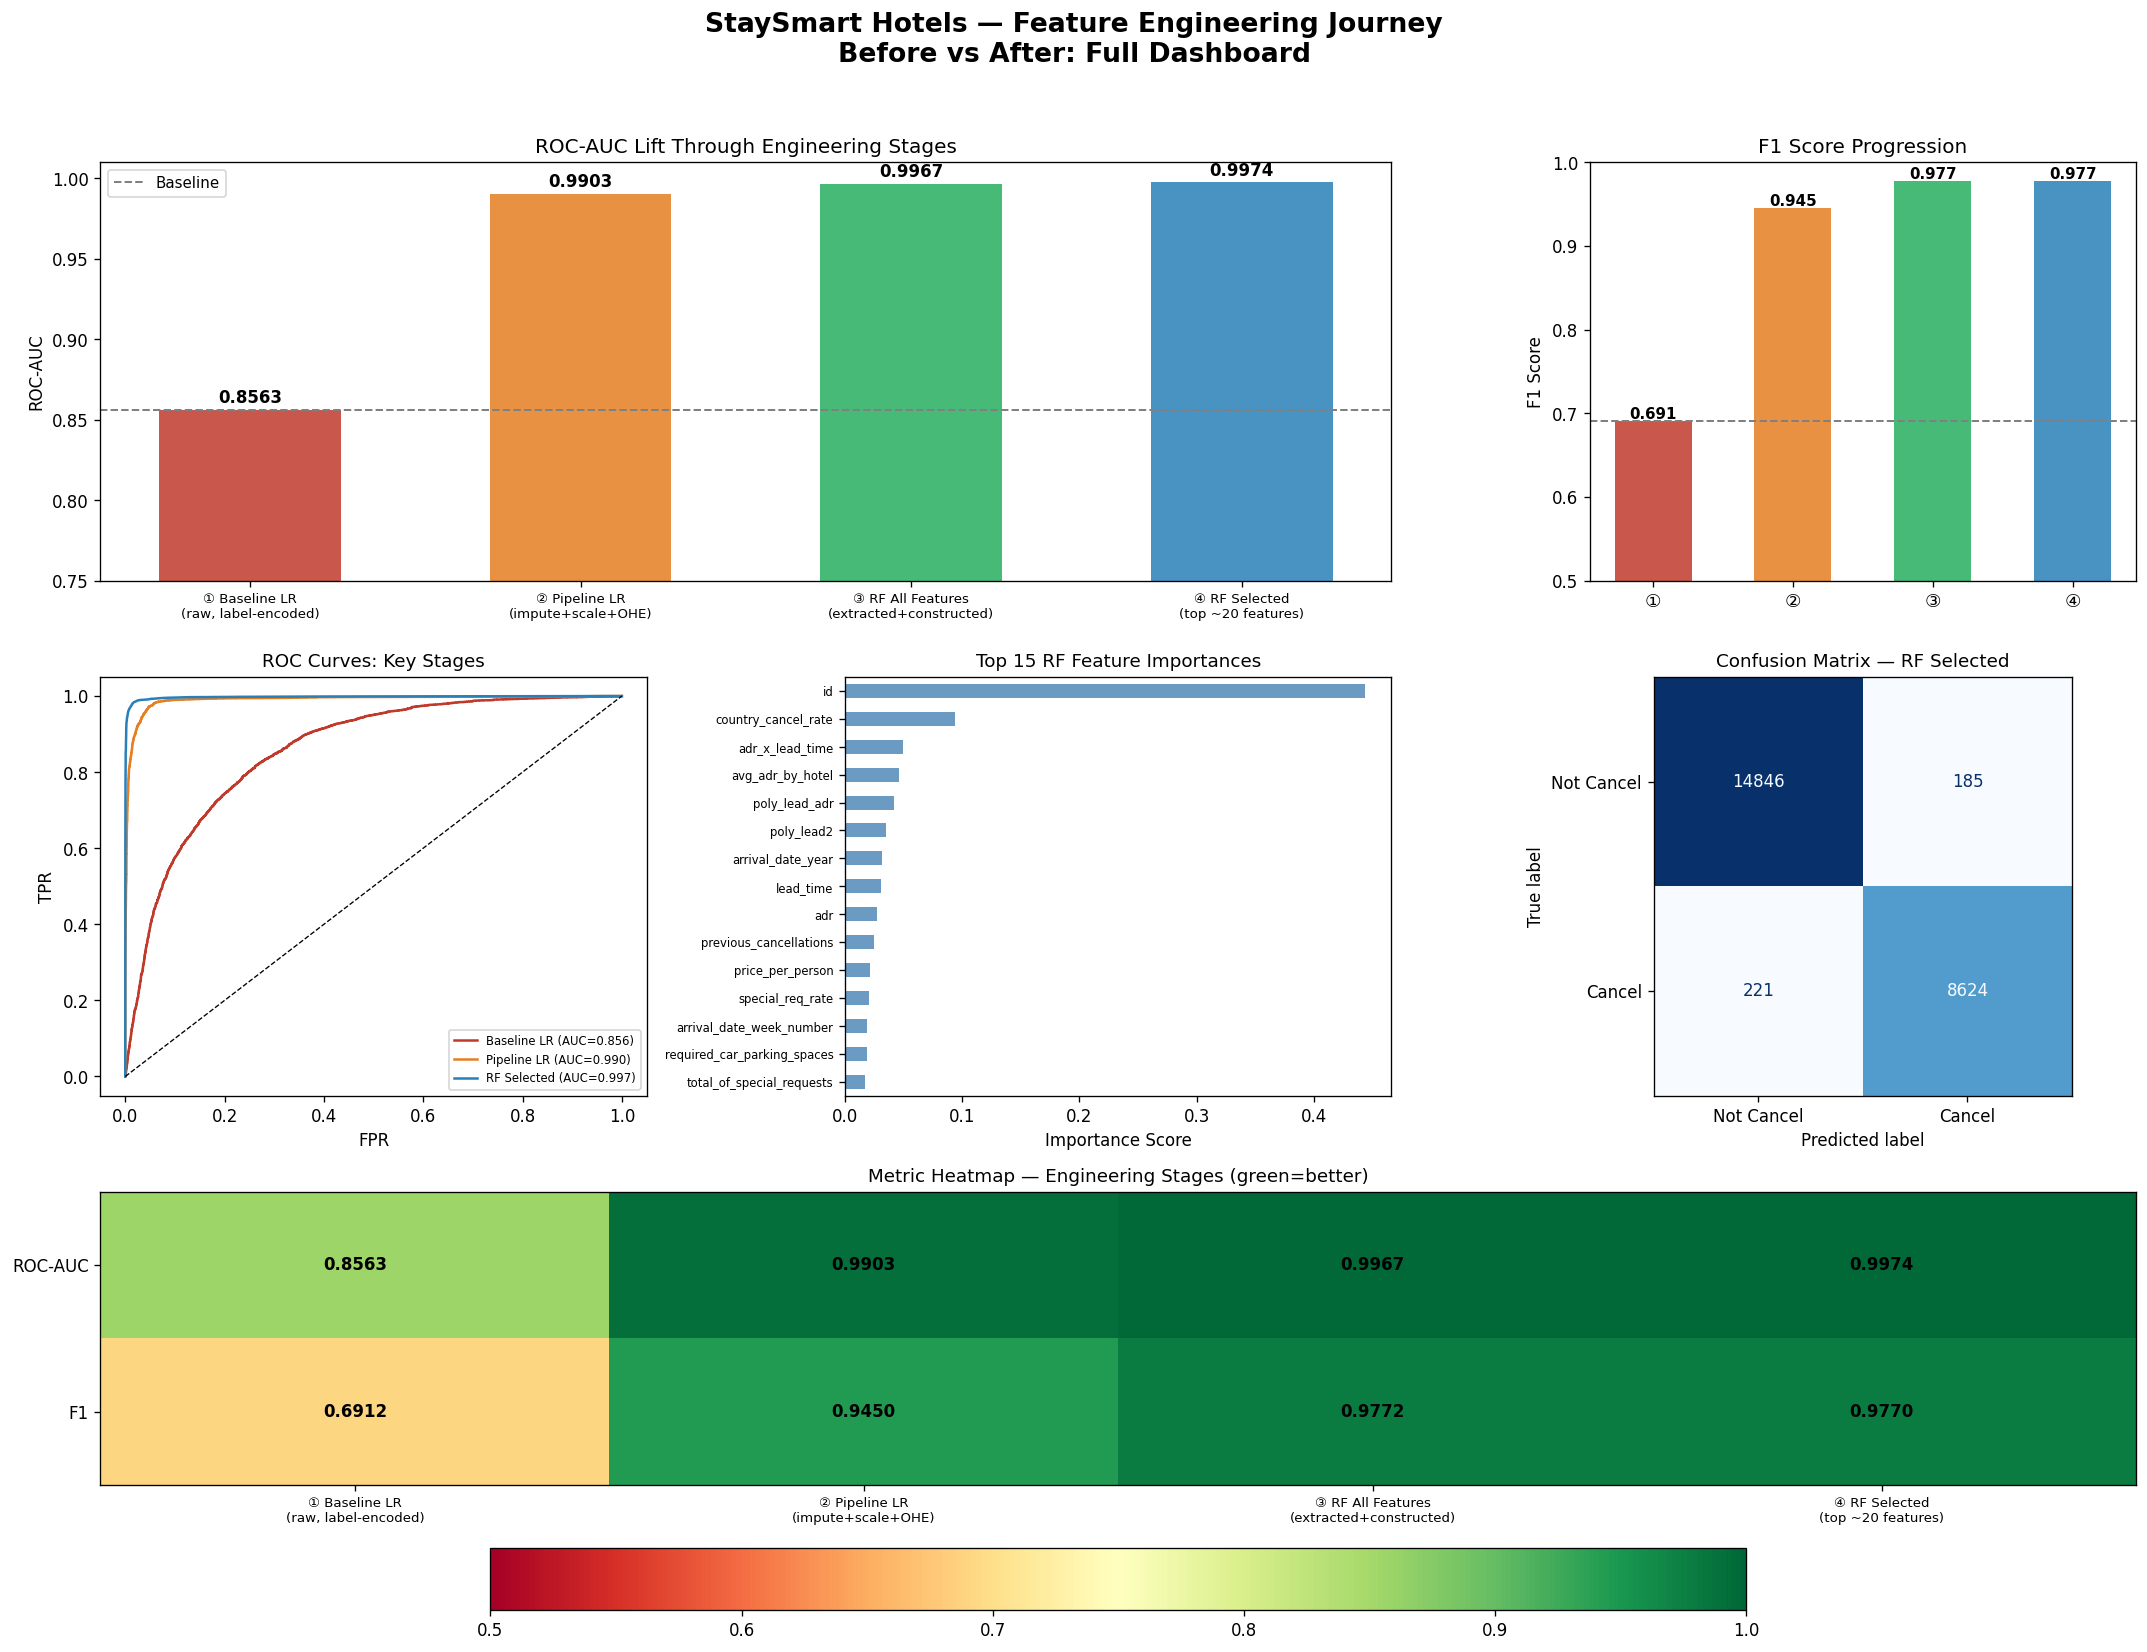


FINAL COMPARISON TABLE
                                     Stage  ROC-AUC     F1  Δ ROC-AUC vs Baseline  Δ F1 vs Baseline
       ① Baseline LR\n(raw, label-encoded)   0.8563 0.6912                 0.0000            0.0000
         ② Pipeline LR\n(impute+scale+OHE)   0.9903 0.9450                 0.1340            0.2538
③ RF All Features\n(extracted+constructed)   0.9967 0.9772                 0.1404            0.2860
         ④ RF Selected\n(top ~20 features)   0.9974 0.9770                 0.1411            0.2858

✅ final_comparison.csv saved


In [24]:
# --- Collect all results ------------------------------------------------
stages = [
    {'Stage': '① Baseline LR\n(raw, label-encoded)',  'ROC-AUC': BASELINE_AUC, 'F1': BASELINE_F1},
    {'Stage': '② Pipeline LR\n(impute+scale+OHE)',    'ROC-AUC': PIPELINE_AUC,  'F1': PIPELINE_F1},
    {'Stage': '③ RF All Features\n(extracted+constructed)', 'ROC-AUC': res8_full['ROC-AUC'], 'F1': res8_full['F1']},
    {'Stage': '④ RF Selected\n(top ~20 features)',    'ROC-AUC': FINAL_AUC,     'F1': FINAL_F1},
]
df_journey = pd.DataFrame(stages)

fig = plt.figure(figsize=(18, 14))
fig.suptitle('StaySmart Hotels — Feature Engineering Journey\n'
             'Before vs After: Full Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

# ── Panel 1: ROC-AUC journey bar ─────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, (1, 2))
colors_ = ['#c0392b','#e67e22','#27ae60','#2980b9']
bars = ax1.bar(df_journey['Stage'], df_journey['ROC-AUC'],
               color=colors_, alpha=0.85, width=0.55)
for bar, v in zip(bars, df_journey['ROC-AUC']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
             f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.set_ylim(0.75, 1.01)
ax1.set_title('ROC-AUC Lift Through Engineering Stages', fontsize=12)
ax1.set_ylabel('ROC-AUC'); ax1.tick_params(axis='x', labelsize=8)
ax1.axhline(BASELINE_AUC, ls='--', color='gray', lw=1.2, label='Baseline')
ax1.legend(fontsize=9)

# ── Panel 2: F1 journey bar ──────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 3, 3)
bars2 = ax2.bar(range(len(df_journey)), df_journey['F1'],
                color=colors_, alpha=0.85, width=0.55)
for bar, v in zip(bars2, df_journey['F1']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_xticks(range(len(df_journey)))
ax2.set_xticklabels(['①','②','③','④'], fontsize=11)
ax2.set_ylim(0.5, 1.0); ax2.set_title('F1 Score Progression', fontsize=12)
ax2.set_ylabel('F1 Score')
ax2.axhline(BASELINE_F1, ls='--', color='gray', lw=1.2)

# ── Panel 3: ROC curve comparison ───────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 4)
roc_pairs = [
    ('Baseline LR', res1['_prob'], res1['_y_te'], '#c0392b'),
    ('Pipeline LR', res5['_prob'], res5['_y_te'], '#e67e22'),
    ('RF Selected', res8['_prob'], res8['_y_te'], '#2980b9')
]
for name, prob, y_true, c in roc_pairs:
    fpr, tpr, _ = roc_curve(y_true, prob)
    ax3.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_true, prob):.3f})', color=c)
ax3.plot([0,1],[0,1],'k--', lw=0.8); ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.set_title('ROC Curves: Key Stages', fontsize=11); ax3.legend(fontsize=7)

# ── Panel 4: Top 15 RF feature importances ──────────────────────────────────
ax4 = fig.add_subplot(3, 3, 5)
rf_imp.head(15).sort_values().plot(kind='barh', ax=ax4, color='steelblue', alpha=0.8)
ax4.set_title('Top 15 RF Feature Importances', fontsize=11)
ax4.set_xlabel('Importance Score'); ax4.tick_params(axis='y', labelsize=7)

# ── Panel 5: Confusion matrix — Final RF ─────────────────────────────────────
ax5 = fig.add_subplot(3, 3, 6)
ConfusionMatrixDisplay(
    confusion_matrix(res8['_y_te'], res8['_pred']),
    display_labels=['Not Cancel','Cancel']
).plot(ax=ax5, colorbar=False, cmap='Blues')
ax5.set_title('Confusion Matrix — RF Selected', fontsize=11)

# ── Panel 6: Metric heatmap across stages ────────────────────────────────────
ax6 = fig.add_subplot(3, 3, (7, 9))
heat_data = df_journey[['ROC-AUC','F1']].values.T
im = ax6.imshow(heat_data, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
ax6.set_xticks(range(len(df_journey)))
ax6.set_xticklabels(df_journey['Stage'], fontsize=8)
ax6.set_yticks([0,1]); ax6.set_yticklabels(['ROC-AUC','F1'], fontsize=10)
for r in range(2):
    for c in range(len(df_journey)):
        ax6.text(c, r, f'{heat_data[r,c]:.4f}', ha='center', va='center', fontsize=10, fontweight='bold')
ax6.set_title('Metric Heatmap — Engineering Stages (green=better)', fontsize=11)
plt.colorbar(im, ax=ax6, orientation='horizontal', pad=0.15)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig('final_dashboard.png', bbox_inches='tight'); plt.show()

# ── Summary Table ─────────────────────────────────────────────────────────────
df_journey['Δ ROC-AUC vs Baseline'] = (df_journey['ROC-AUC'] - BASELINE_AUC).round(4)
df_journey['Δ F1 vs Baseline']      = (df_journey['F1']      - BASELINE_F1).round(4)
print('\n' + '='*70)
print('FINAL COMPARISON TABLE')
print('='*70)
print(df_journey[['Stage','ROC-AUC','F1','Δ ROC-AUC vs Baseline','Δ F1 vs Baseline']].to_string(index=False))
df_journey.to_csv('final_comparison.csv', index=False)
print('\n✅ final_comparison.csv saved')